/net/dali/home/mscbio/rul98/PheOpt/map_explore/paper0815.ipynb

In [1]:
import numpy as np
import pandas as pd
years = [2017, 2018, 2019, 2020, 2021, 2022]
states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming']
df = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/2022_US_weekly_symptoms_dataset.csv')
symptom_cols = [col for col in df.columns if col.startswith('symptom:')]
usecols = ['sub_region_1', 'date'] + symptom_cols

dfs = []
for year in years:
    df = pd.read_csv(f'/net/dali/home/mscbio/rul98/covid19_symptom_dataset/{year}_US_weekly_symptoms_dataset.csv', usecols=usecols)
    df.columns = [col.replace('symptom:', '') for col in df.columns]
    df = df[df['sub_region_1'].isin(states)]
    df['date'] = pd.to_datetime(df['date'])
    dfs.append(df)
weekly_df = pd.concat(dfs)
weekly_df.shape

(13872, 424)

In [2]:
import numpy as np
import pandas as pd
years = [2017, 2018, 2019, 2020, 2021, 2022]
states = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming']
df = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/2022_US_daily_symptoms_dataset.csv')
symptom_cols = [col for col in df.columns if col.startswith('symptom:')]
usecols = ['sub_region_1', 'date'] + symptom_cols

dfs = []
for year in years:
    df = pd.read_csv(f'/net/dali/home/mscbio/rul98/covid19_symptom_dataset/{year}_US_daily_symptoms_dataset.csv', usecols=usecols)
    df.columns = [col.replace('symptom:', '') for col in df.columns]
    df = df[df['sub_region_1'].isin(states)]
    df['date'] = pd.to_datetime(df['date'])
    dfs.append(df)
full_df = pd.concat(dfs)
full_df.shape

(97767, 424)

In [3]:
weekly_dfs = {}
symptom_cols = [col.replace('symptom:', '') for col in symptom_cols]
for symptom_col in symptom_cols:
    df_pivot = weekly_df.pivot(index='date', columns='sub_region_1', values=symptom_col)
    df_log = np.log(df_pivot)
    weekly_dfs[symptom_col] = df_log
    
dfs = {}
for symptom_col in symptom_cols:
    df_pivot = full_df.pivot(index='date', columns='sub_region_1', values=symptom_col)
    df_log = np.log(df_pivot)
    dfs[symptom_col] = df_log.fillna(0)

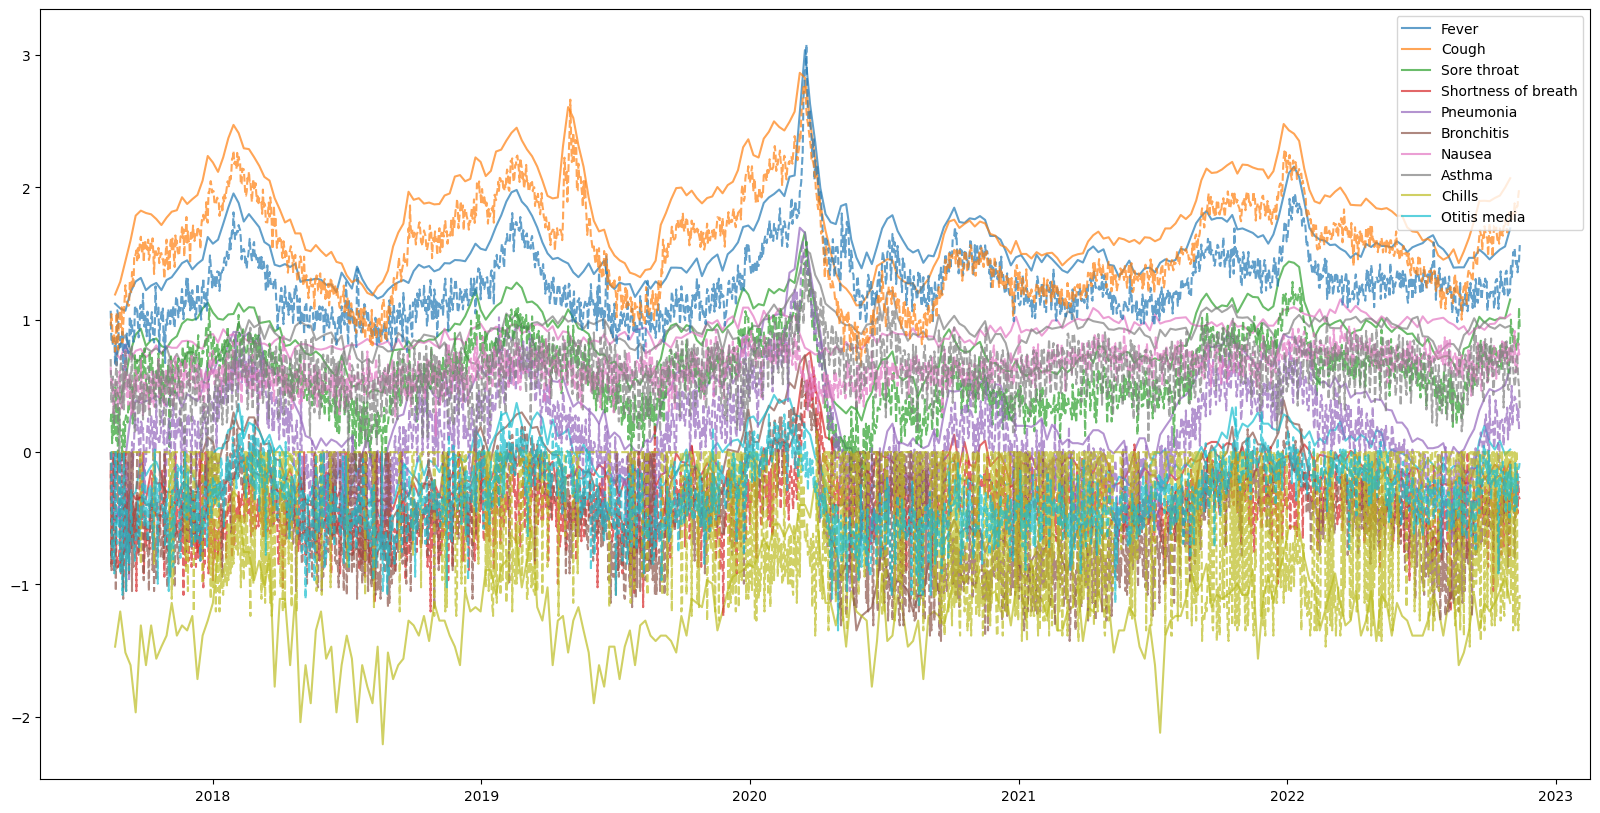

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(weekly_dfs[s]['Montana'], label = s, alpha = 0.7)
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['Montana'], linestyle = '--', alpha = 0.7)
plt.legend();
    

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dfs = {}
symptom_cols = [col.replace('symptom:', '') for col in symptom_cols]
for symptom_col in symptom_cols:
    df_pivot = full_df.pivot(index='date', columns='sub_region_1', values=symptom_col)
    # df_log = pd.DataFrame(scaler.fit_transform(np.log(df_pivot)), index=df_pivot.index, columns=df_pivot.columns)
    df_log = np.log(df_pivot)
    df_scaled = df_log.copy()
    for col in df_log.columns:
        s = df_log[col]
        n_valid = s.notna().sum()
        if n_valid < 2:
            continue
        ss = StandardScaler()
        ss.fit(s.dropna().to_frame())
        df_scaled.loc[s.notna(), col] = ss.transform(s.dropna().to_frame()).ravel()
    
    df_ma7 = df_scaled.rolling(7, min_periods=3).mean()
    df_ma7 = df_ma7.iloc[6:]
    
    # A) Interpolate inside gaps using the datetime index
    # Ensure index is datetime: full_df['date'] = pd.to_datetime(full_df['date'])
    df_imp = df_ma7.interpolate(method='time', limit=3, limit_area='inside')

    # B) Short ffill/bfill for small leading/trailing gaps
    df_imp = df_imp.ffill(limit=3).bfill(limit=3)
    
    dfs[symptom_col] = df_imp.fillna(0)

In [6]:
# na_sum_df = pd.DataFrame()
# for symptom_col, df_pivot in dfs.items():
#     na_sum = (df_pivot.isna()).sum()
#     na_sum.name = symptom_col
#     na_sum_df = pd.concat([na_sum_df, na_sum.to_frame().T])
# na_sum_df["na_sum"] = na_sum_df.sum(axis=1)
# na_sum_df = na_sum_df.sort_values("na_sum", ascending=True).drop(columns="na_sum")
# # na_sum_df.to_csv('na_sum_df.csv')
# na_sum_df

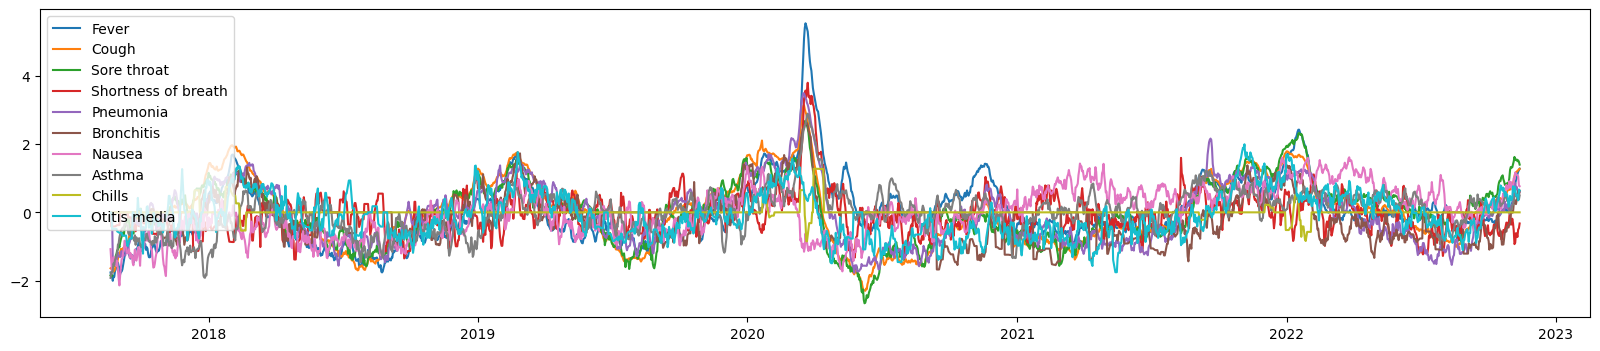

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['Wyoming'], label = s)
plt.legend()

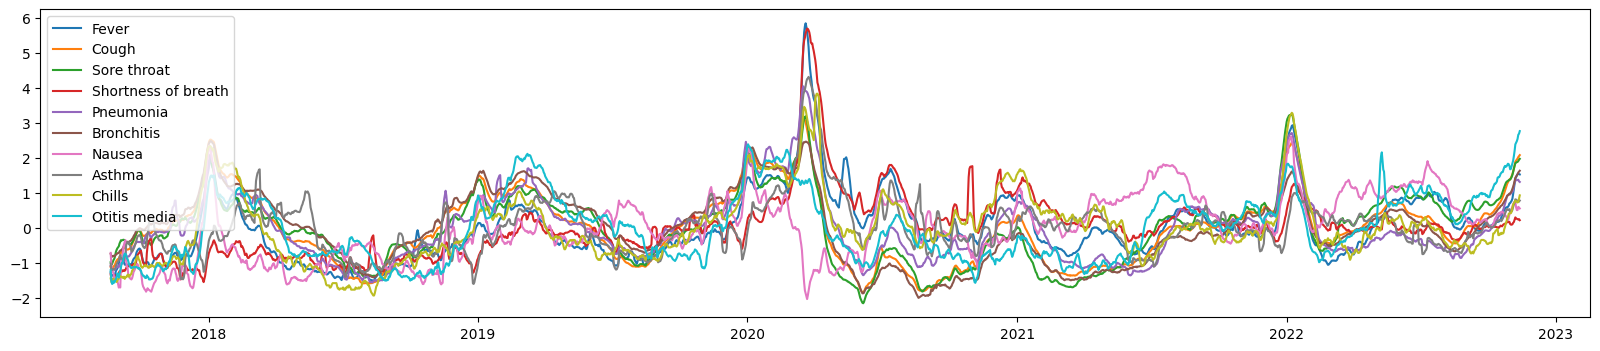

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['California'], label = s)
plt.legend()

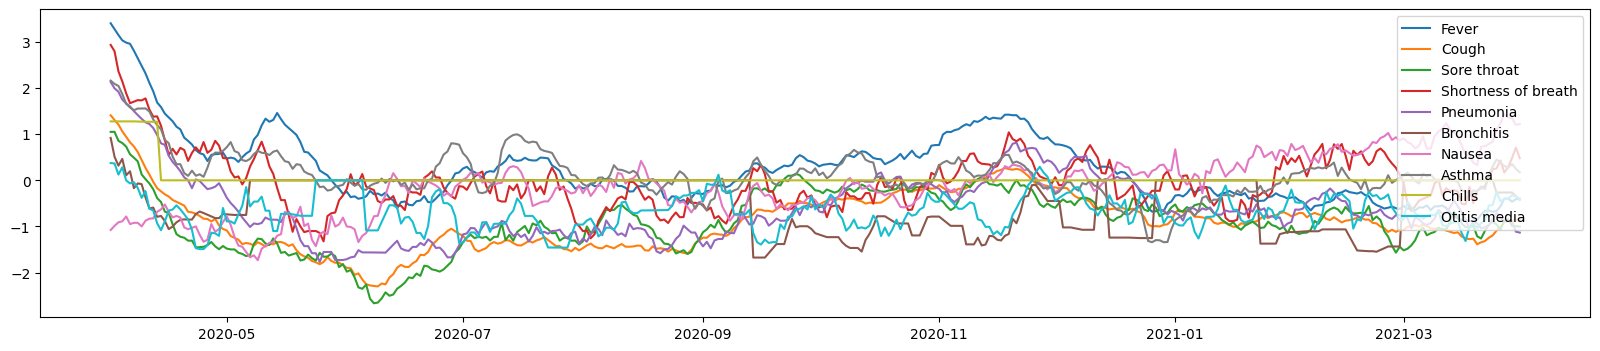

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['Wyoming'][954:1319], label = s)
plt.legend()

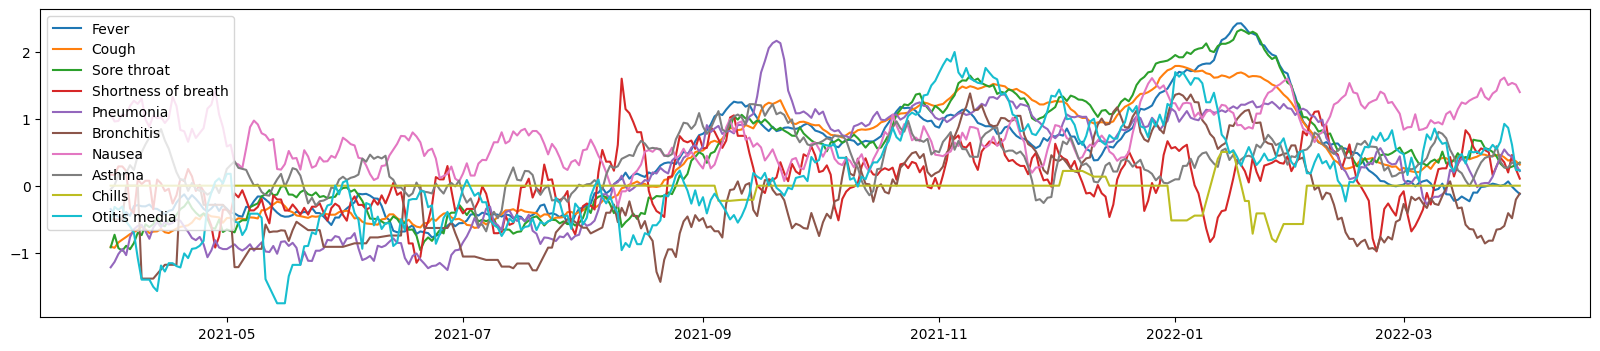

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['Wyoming'][1319:1684], label = s)
plt.legend()

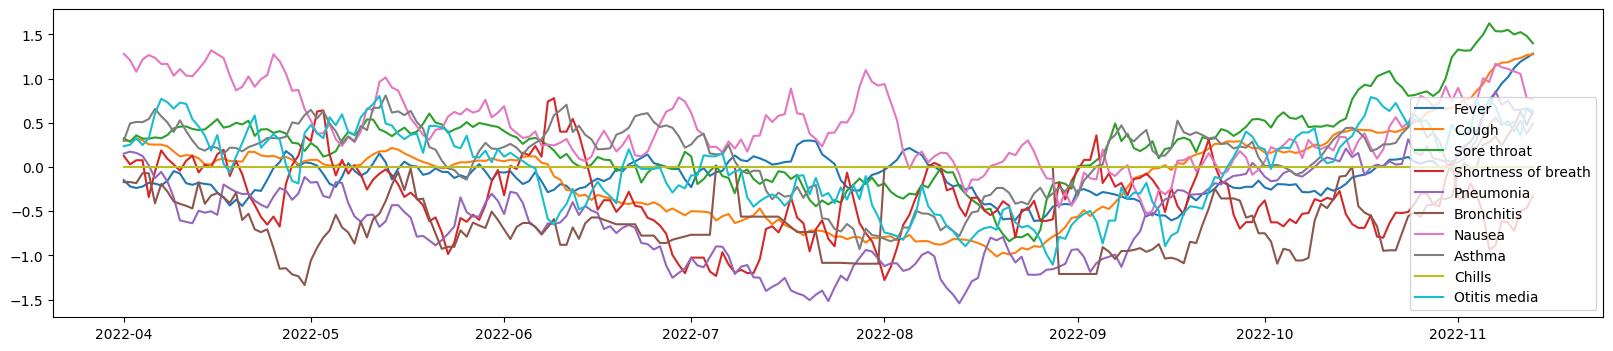

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
for s in ["Fever", "Cough", "Sore throat", "Shortness of breath", "Pneumonia", "Bronchitis", "Nausea", "Asthma", "Chills", "Otitis media"]:
    plt.plot(dfs[s]['Wyoming'][1684:], label = s)
plt.legend()

<Axes: xlabel='time_value'>

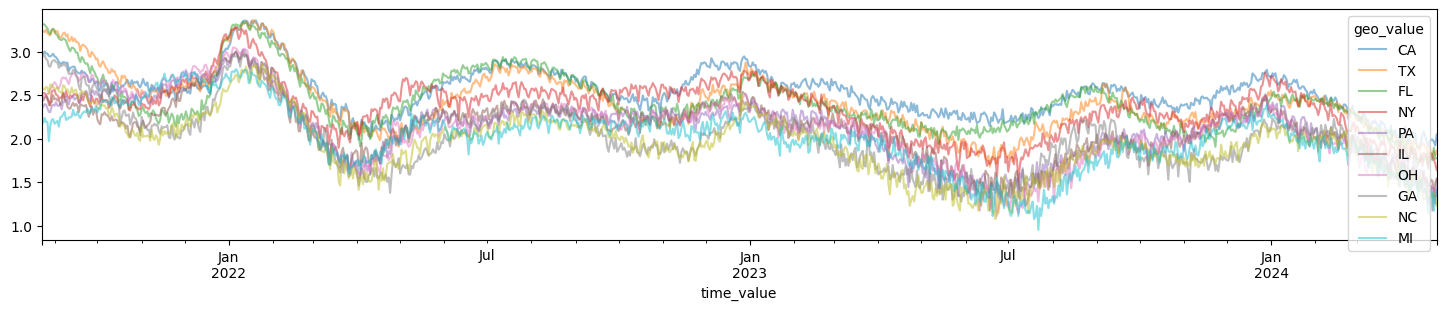

In [16]:
import pandas as pd
import numpy as np
HHShosp = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/covidcast/covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2025-08-15.csv', index_col = 0)
HHShosp['geo_value'] = HHShosp['geo_value'].str.upper()
HHShosp['time_value'] = pd.to_datetime(HHShosp['time_value'], format = '%Y-%m-%d')
HHShosp = HHShosp.pivot(values='value', columns='geo_value', index='time_value')
HHShosp = HHShosp.dropna()
HHShosp[HHShosp < 0] = 0
np.log10(HHShosp[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']] + 1).plot(figsize = (18, 3), alpha = 0.5)

In [17]:
HHShosp

geo_value,AK,AL,AR,AS,AZ,CA,CO,CT,DC,DE,...,TN,TX,UT,VA,VI,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2021-08-23,21.0,377.0,190.0,0.0,214.0,971.0,132.0,61.0,23.0,26.0,...,362.0,1762.0,82.0,178.0,1.0,11.0,180.0,156.0,75.0,46.0
2021-08-24,15.0,379.0,166.0,0.0,196.0,948.0,97.0,58.0,17.0,22.0,...,372.0,1724.0,70.0,185.0,0.0,5.0,163.0,148.0,64.0,46.0
2021-08-25,33.0,390.0,167.0,0.0,204.0,1004.0,127.0,58.0,17.0,24.0,...,385.0,1680.0,78.0,207.0,0.0,7.0,158.0,149.0,81.0,43.0
2021-08-26,18.0,397.0,196.0,0.0,208.0,951.0,145.0,48.0,17.0,30.0,...,373.0,1807.0,69.0,211.0,0.0,8.0,159.0,157.0,108.0,38.0
2021-08-27,21.0,334.0,167.0,0.0,229.0,954.0,114.0,53.0,21.0,35.0,...,401.0,1631.0,68.0,189.0,0.0,6.0,176.0,166.0,101.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-22,0.0,20.0,4.0,0.0,10.0,97.0,15.0,7.0,1.0,4.0,...,21.0,66.0,5.0,28.0,1.0,0.0,15.0,14.0,4.0,2.0
2024-04-23,0.0,14.0,14.0,0.0,16.0,97.0,15.0,6.0,2.0,3.0,...,22.0,66.0,3.0,26.0,0.0,1.0,12.0,18.0,6.0,1.0
2024-04-24,1.0,12.0,4.0,0.0,14.0,92.0,12.0,6.0,0.0,4.0,...,12.0,71.0,11.0,26.0,0.0,0.0,14.0,15.0,7.0,0.0


<Axes: xlabel='time_value'>

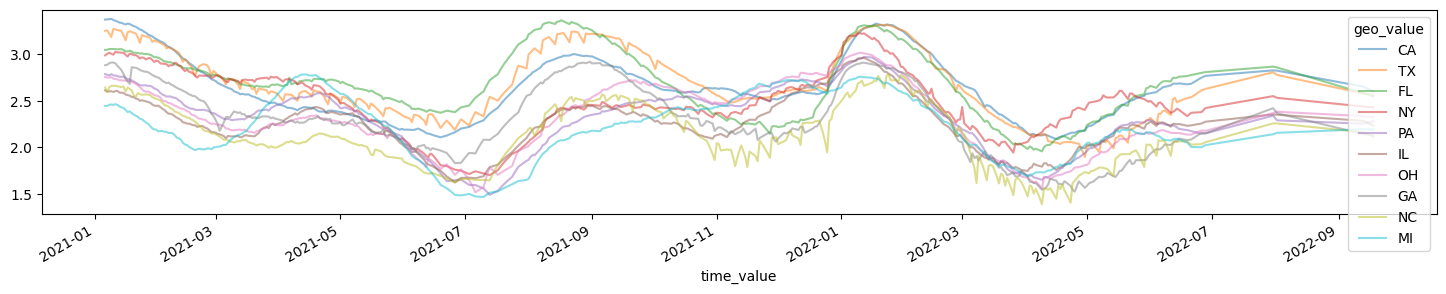

In [ ]:
import pandas as pd
import numpy as np
CPRhosp = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/covidcast/covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2025-08-15.csv', index_col = 0)
CPRhosp['geo_value'] = CPRhosp['geo_value'].str.upper()
CPRhosp['time_value'] = pd.to_datetime(CPRhosp['time_value'], format = '%Y-%m-%d')
CPRhosp = CPRhosp.pivot(values='value', columns='geo_value', index='time_value')
CPRhosp = CPRhosp.dropna()
CPRhosp[CPRhosp < 0] = 0
np.log10(CPRhosp[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']] + 1).plot(figsize = (18, 3), alpha = 0.5)

In [ ]:
CPRhosp

geo_value,AK,AL,AR,AS,AZ,CA,CO,CT,DC,DE,...,TN,TX,UT,VA,VI,VT,WA,WI,WV,WY
time_value,,,,,,,,,,,,,,,,,,,,,
2021-01-06,11.857143,408.571429,168.428571,0.000000,568.142857,2335.714286,139.857143,138.285714,37.142857,49.285714,...,364.857143,1764.428571,86.142857,283.571429,0.000000,6.714286,101.714286,239.142857,90.285714,16.000000
2021-01-07,11.714286,410.571429,169.000000,0.000000,568.142857,2350.142857,130.428571,139.714286,37.000000,47.000000,...,364.285714,1792.285714,88.714286,293.428571,0.000000,8.142857,101.428571,235.857143,89.714286,17.714286
2021-01-08,11.428571,411.285714,170.000000,0.000000,582.142857,2357.428571,121.000000,142.714286,38.714286,50.428571,...,366.714286,1650.428571,90.142857,291.428571,0.000000,8.428571,97.428571,237.857143,90.142857,18.285714
2021-01-09,10.857143,418.857143,172.571429,0.000000,580.857143,2379.000000,114.857143,129.428571,37.428571,48.142857,...,357.142857,1522.142857,94.571429,288.714286,0.000000,9.000000,97.714286,241.142857,89.714286,16.285714
2021-01-10,8.571429,409.571429,177.428571,0.000000,579.428571,2314.000000,116.428571,110.142857,36.000000,44.285714,...,340.142857,1853.000000,93.000000,293.000000,0.000000,9.000000,96.571429,235.428571,89.714286,16.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-31,18.142857,119.428571,61.285714,0.571429,105.000000,666.857143,69.857143,62.285714,20.142857,21.000000,...,113.857143,636.571429,50.571429,124.571429,1.428571,6.857143,91.000000,88.142857,54.714286,10.714286
2022-08-01,16.714286,115.857143,60.357143,0.500000,105.785714,664.571429,69.785714,61.857143,19.357143,20.642857,...,110.214286,616.071429,49.857143,125.642857,1.142857,5.857143,92.285714,88.071429,55.714286,10.142857
2022-08-02,15.285714,112.285714,59.428571,0.428571,106.571429,662.285714,69.714286,61.428571,18.571429,20.285714,...,106.571429,595.571429,49.142857,126.714286,0.857143,4.857143,93.571429,88.000000,56.714286,9.571429


<Axes: xlabel='time_value'>

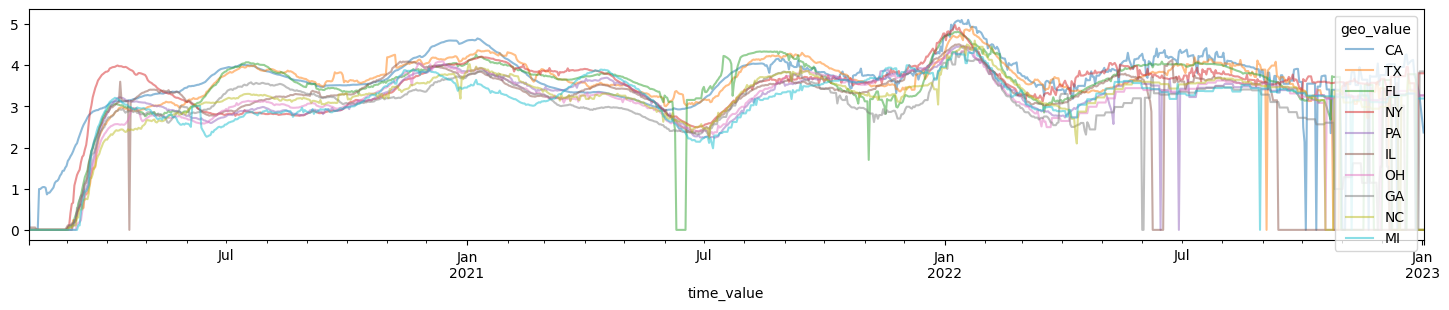

In [21]:
import pandas as pd
import numpy as np
USFcase = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/covidcast/covidcast-usa-facts-confirmed_7dav_incidence_num-2020-02-01-to-2025-08-15.csv', index_col = 0)
USFcase['geo_value'] = USFcase['geo_value'].str.upper()
USFcase['time_value'] = pd.to_datetime(USFcase['time_value'], format = '%Y-%m-%d')
USFcase = USFcase.pivot(values='value', columns='geo_value', index='time_value')
USFcase = USFcase.dropna()
USFcase[USFcase < 0] = 0
np.log10(USFcase[['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI']] + 1).plot(figsize = (18, 3), alpha = 0.5)

In [12]:
import numpy as np
import pandas as pd
years = [2017, 2018, 2019, 2020, 2021, 2022]
states = ['Australian Capital Territory', 'New South Wales',
       'Northern Territory', 'Queensland', 'South Australia', 'Tasmania',
       'Victoria', 'Western Australia']
df = pd.read_csv('/net/dali/home/mscbio/rul98/covid19_symptom_dataset/2022_AU_daily_symptoms_dataset.csv')
symptom_cols = [col for col in df.columns if col.startswith('symptom:')]
usecols = ['sub_region_1', 'date'] + symptom_cols

dfs = []
for year in years:
    df = pd.read_csv(f'/net/dali/home/mscbio/rul98/covid19_symptom_dataset/{year}_AU_daily_symptoms_dataset.csv', usecols=usecols)
    df.columns = [col.replace('symptom:', '') for col in df.columns]
    df = df[df['sub_region_1'].isin(states)]
    df['date'] = pd.to_datetime(df['date'])
    dfs.append(df)
full_df = pd.concat(dfs)
full_df.shape

(14536, 424)

In [13]:
dfs = {}
symptom_cols = [col.replace('symptom:', '') for col in symptom_cols]
for symptom_col in symptom_cols:
    df_pivot = full_df.pivot(index='date', columns='sub_region_1', values=symptom_col)
    dfs[symptom_col] = df_pivot

In [14]:
na_sum_df = pd.DataFrame()

for symptom_col, df_pivot in dfs.items():
    na_sum = (df_pivot.isna()).sum()
    na_sum.name = symptom_col
    na_sum_df = pd.concat([na_sum_df, na_sum.to_frame().T])
na_sum_df["na_sum"] = na_sum_df.sum(axis=1)
na_sum_df = na_sum_df.sort_values("na_sum", ascending=True).drop(columns="na_sum")
na_sum_df

sub_region_1,Australian Capital Territory,New South Wales,Northern Territory,Queensland,South Australia,Tasmania,Victoria,Western Australia
Allergy,0,0,0,0,0,0,0,0
Pain,0,0,0,0,0,0,0,0
Skin rash,0,0,0,0,0,0,0,0
Infection,0,0,0,0,0,0,0,0
Anxiety,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
Shallow breathing,1803,192,1813,747,1742,1806,317,1588
Burning Chest Pain,1806,188,1807,1026,1766,1810,417,1677
Ageusia,1796,394,1813,959,1732,1801,421,1591
Viral pneumonia,1799,410,1809,1029,1746,1805,794,1634


In [15]:
# na_sum_df.to_csv('na_sum_AU.csv')